# Домашнее задание 4 - Непараметрические критерии


## Задача 1 (5 баллов)




1.   Сгенерить самостоятельно 2 распределения, нормальное с любыми параметрами и размером 1000 и биномиальное с параметрами 1, 0.5 и размером 100
2.   Для каждого распределения
    *   Построить Q-Q plot
    *   Проверить нормальность с помощью критерия согласия Колмогорова
    *   Проверить нормальность с помощью критерия Шапиро-Уилка
    *   Проверить то что ваши распределения имееют общее распределение с помощью критерия однородности Смирнова
3.   Собрать новую выборку из ваших 2 сгенирированных распределений. Для этого взять случайных 900 элементов из нормального распределения и добавить к ним выборку с биномиальным распределением, чтобы снова получили выборки из 1000 элементов
4.   Для новой "собранной выборки"
    *   Построить Q-Q plot
    *   Проверить нормальность с помощью критерия согласия Колмогорова
    *   Проверить нормальность с помощью критерия Шапиро-Уилка
5.  Из выборки с нормальным распределением получить новую выборку. Сделаем это с помощью "докидывания эффекта". Взять текущую выборку с нормальным распределением и рандомные 500 элементов увеличить на 5%, остальные оставим без изменений
6. Для новой выборки с "докинутым эффектом"
    *   Построить Q-Q plot
    *   Проверить нормальность с помощью критерия согласия Колмогорова
    *   Проверить нормальность с помощью критерия Шапиро-Уилка
    *   Проверить то что ваши распределения(изначальное нормальное из п1 и полученное в п5) имееют общее распределение с помощью критерия однородности Смирнова





















In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from numpy.typing import NDArray


In [2]:
# 1

n_size, b_size = 1000, 100

loc, scale = 2, 10
n, p = 1, .5

normal_dist = stats.norm(loc=loc, scale=scale).rvs(n_size)
binom_dist = stats.binom(n=n, p=p).rvs(b_size)

In [3]:
# 2
def task_1(
        dist: NDArray,
        alpha: float = .05
) -> None:
    stats.probplot(dist, dist="norm", plot=plt)
    plt.show()
    ks_statistic, p_value = stats.kstest(dist, "norm", args=(dist.mean(), dist.std(ddof=1)))
    print(
        "Критерия Колмогорова: выборка{no} соответствует нормальному распределению ({p})".format(no=" не" if p_value < alpha else "", p=p_value)
    )
    _, p_value = stats.shapiro(dist)
    print(
        "Критерий Шапиро-Уилка: выборка{no} соответствует нормальному распределению ({p})".format(no=" не" if p_value < alpha else "", p=p_value)
    )


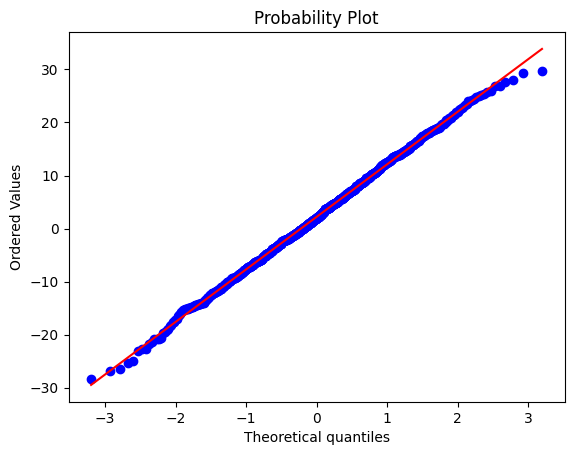

Критерия Колмогорова: выборка соответствует нормальному распределению (0.9914076575997938)
Критерий Шапиро-Уилка: выборка соответствует нормальному распределению (0.7350950529245166)


In [4]:
task_1(normal_dist)

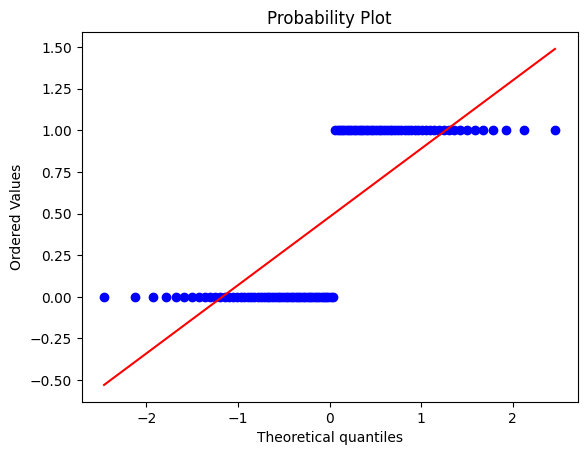

Критерия Колмогорова: выборка не соответствует нормальному распределению (1.743775927125201e-11)
Критерий Шапиро-Уилка: выборка не соответствует нормальному распределению (2.1735753688913795e-14)


In [5]:
task_1(binom_dist)

In [6]:
alpha = .05
_, p_value = stats.ks_2samp(normal_dist, binom_dist)

print(
        "Критерий однородности Смирнова: выборки{no} имеют общее распределение".format(no=" не" if p_value < alpha else "")
)

Критерий однородности Смирнова: выборки не имеют общее распределение


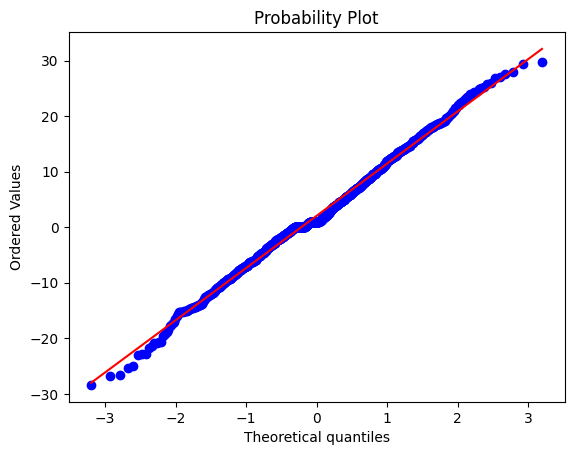

Критерия Колмогорова: выборка не соответствует нормальному распределению (0.0016519843357176828)
Критерий Шапиро-Уилка: выборка не соответствует нормальному распределению (0.001684749154002436)


In [7]:
# 3

assert len(normal_dist) > len(binom_dist)
almost_normal_dist = np.concatenate((normal_dist[len(binom_dist):], binom_dist))

task_1(almost_normal_dist)

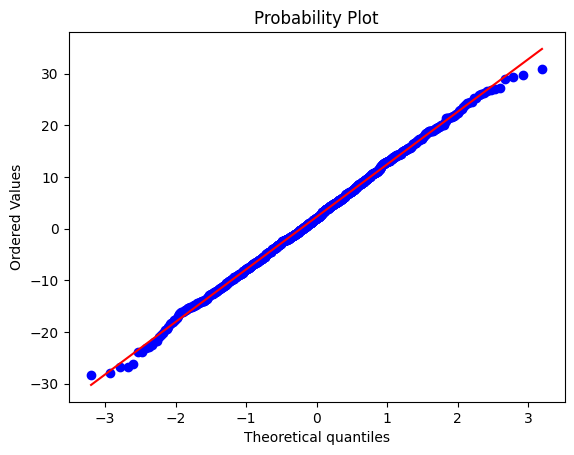

Критерия Колмогорова: выборка соответствует нормальному распределению (0.9276205360500213)
Критерий Шапиро-Уилка: выборка соответствует нормальному распределению (0.6532804111658207)


In [10]:
multiplier = 1.05
n_multiply = 500
idx = np.random.choice(n_size, n_multiply, replace=False)

dist = normal_dist.copy()

dist[idx] *= multiplier

task_1(dist)

In [13]:
alpha = .05
_, p_value = stats.ks_2samp(normal_dist, dist)

print(
        "Критерий однородности Смирнова: выборки{no} имеют общее распределение".format(no=" не" if p_value < alpha else "")
)

Критерий однородности Смирнова: выборки имеют общее распределение


## Задача 2 (4 балла)

Для данных из файла employees.xls постройте гистограмму для переменной SALARY. Проверьте нормальность этих данных с помощью:
  * Q-Q plot
  * Критерия Колмогорова
  * Критерия Шапиро-Уилка


In [14]:
!curl -O https://raw.githubusercontent.com/YuriyKotov/datasets/master/employees.xls >> employees.xls

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 26624  100 26624    0     0  67300      0 --:--:-- --:--:-- --:--:-- 67402


In [15]:
import pandas as pd

df = pd.read_excel('employees.xls')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  100 non-null    object
 1   GENDER      100 non-null    object
 2   DEPART      100 non-null    object
 3   EDUC        100 non-null    object
 4   AGE         100 non-null    int64 
 5   HEIGHT      100 non-null    int64 
 6   SENIOR      100 non-null    int64 
 7   SALARY      100 non-null    int64 
 8   INI_PROF    100 non-null    int64 
 9   CUR_PROF    100 non-null    int64 
dtypes: int64(6), object(4)
memory usage: 7.9+ KB


In [17]:
df.head()

,Unnamed: 0,GENDER,DEPART,EDUC,AGE,HEIGHT,SENIOR,SALARY,INI_PROF,CUR_PROF
0,Alexander,Female,Ship,College,22,63,4,23400,82,90
1,Arcones,Male,Package,College,49,65,17,40400,89,123
2,Barber,Male,Bake,College,36,67,8,29400,77,93
3,Barrera,Male,Package,HS,37,67,3,24800,102,108
4,Bester,Male,Ship,Grad,43,66,11,31200,82,104


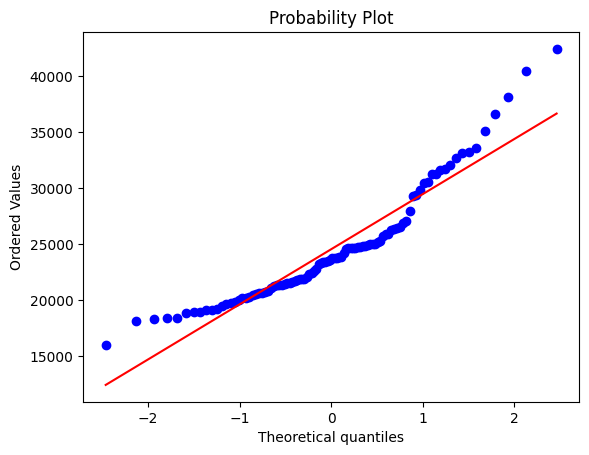

Критерия Колмогорова: выборка не соответствует нормальному распределению (0.01678820637964868)
Критерий Шапиро-Уилка: выборка не соответствует нормальному распределению (1.664645028598051e-06)


In [18]:
salary = df['SALARY'].to_numpy()

task_1(salary)

## Задача 3 (3 балла)

Для данных из файла employees.xls проверить с помощью критерия знаков и рангового критерия гипотезу что медианная зарплата равна 25000

In [ ]:
from statsmodels.stats.descriptivestats import sign_test

alpha = .05

expected_salary = 25000

_, p_value = sign_test(salary, mu0=expected_salary)

if p_value < alpha:
    print(f"Критерий знаков: не принимаем H0 медиана не равна {expected_salary}")
else:
    print(f"ритерий знаков: принимаем Н0: медиана может быть равна {expected_salary}")

print(f"p-value: {p_value:.6f}")

Критерий знаков: не принимаем H0 медиана не равна 25000
p-value: 0.000490


In [24]:
_, p_value = stats.wilcoxon(salary - expected_salary)
if p_value < alpha:
    print(f"Критерий Уилкоксона: не принимаем H0: медиана не равна {expected_salary}")
else:
    print(f"Критерий Уилкоксона: принимаем Н0: медиана может быть равна {expected_salary}")
print(f"p-value: {p_value:.6f}")


Критерий Уилкоксона: не принимаем H0: медиана не равна 25000
p-value: 0.041320


## Задача 4 (3 балла)

В файле anorexia.txt записан вес пациентов до и после начала терапии от анорексии. С помощью критерия знаков и рангового критерия проверить, была ли эффективна данная терапия

In [35]:
!curl -O https://raw.githubusercontent.com/YuriyKotov/datasets/master/anorexia.txt >> anorexia.txt

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0

100   355  100   355    0     0   1049      0 --:--:-- --:--:-- --:--:--  1053


In [36]:
df = pd.read_csv('anorexia.txt', sep='\t')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Before  29 non-null     float64
 1   After   29 non-null     float64
dtypes: float64(2)
memory usage: 592.0 bytes


In [37]:
df.head()

,Before,After
0,80.5,82.2
1,84.9,85.6
2,81.5,81.4
3,82.6,81.9
4,79.9,76.4


In [42]:
diff = (df['After'] - df['Before']).replace(0, np.nan).to_numpy()
_, p_value = sign_test(diff)
if (p_value < alpha):
    print(f"Критерий знаков: не принимаем H0: эффекта нет")
else:
    print(f"Критерий знаков: принимаем H0: эффект может быть")
print(f"p-value: {p_value}")


Критерий знаков: принимаем H0: эффект может быть
p-value: 0.26493089646101


In [43]:
_, p_value = stats.wilcoxon(diff)
if (p_value < alpha):
    print(f"Критерий знаков: не принимаем H0: эффекта нет")
else:
    print(f"Критерий знаков: принимаем H0: эффект может быть")
print(f"p-value: {p_value}")


Критерий знаков: принимаем H0: эффект может быть
p-value: 0.06551516801118851


## Задача 5 (3 балла)

В файле seattle.txt записаны цены на объекты недвижимости в одном районе из районов Сиетла в 2001 и 2002 году (объекты выбирались случайно). Изменились ли средние цены в этом районе за год? Проверить это с помощью критерия знаков и рангового критерия

In [44]:
!curl -O https://raw.githubusercontent.com/YuriyKotov/datasets/master/seattle.txt >> seattle.txt

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   996  100   996    0     0   2289      0 --:--:-- --:--:-- --:--:--  2289


In [70]:
df = pd.read_csv('seattle.txt', sep='\t')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Price   100 non-null    float64
 1   Year    100 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 1.7 KB


In [ ]:

df.head()

,Price,Year
0,142.0,2002
1,232.0,2002
2,132.5,2002
3,200.0,2002
4,362.0,2002


In [83]:
critical_values = pd.DataFrame([
[5,	0	,np.nan],
[6,	2	,np.nan],
[7,	3	,0],
[8,	5	,1],
[9,	8	,3],
[10,	10,	5],
[11,	13,	7],
[12,	17,	9],
[13,	21,	12],
[14,	25,	15],
[15,	30,	19],
[16,	35,	23],
[17,	41,	27],
[18,	47,	32],
[19,	53,	37],
[20,	60,	43],
[21,	67,	49],
[22,	75,	55],
[23,	83,	62],
[24,	91,	69],
[25,	100,	76],
[26,	110,	84],
[27,	119,	92],
[28,	130,	101],
[29,	140,	110],
[30,	151,	120],
[31,	163,	130],
[32,	175,	140],
[33,	187,	151],
[34,	200,	162],
[35,	213,	173],
[36,	227,	185],
[37,	241,	198],
[38,	256,	211],
[39,	271,	224],
[40,	286,	238],
[41,	302,	252],
[42,	319,	266],
[43,	336,	281],
[44,	353,	296],
[45,	371,	312],
[46,	389,	328],
[47,	407,	345],
[48,	426,	362],
[49,	446,	379],
[50,	466,	397],
],
columns=['n', 'p<.05', 'p<.01']).set_index('n')


In [140]:
def sign_test_from_scratch(data1: NDArray, data2: NDArray) -> None:
    assert data1.shape == data2.shape
    assert len(data1) < 51

    # h0: med(data1-data2) = 0
    # h1: med(data1-data2) != 0

    diff = data1 - data2
    non_zero = diff[diff != 0]
    ranks = {}
    curr_rank = 0
    curr_cnt = 1
    non_zero_non_sign = sorted(np.abs(non_zero))
    curr_val = None
    for i, val in enumerate(non_zero_non_sign):
        if val != curr_val:
            ranks[curr_val] = curr_rank / curr_cnt
            curr_val = val
            curr_rank = i+1
            curr_cnt = 1
        else:
            curr_cnt += 1
            curr_rank += i+1
    ranks[curr_val] = curr_rank / curr_cnt
    Tm = sum(ranks[abs(val)] for val in non_zero if val < 0) 
    Tp = sum(ranks[abs(val)] for val in non_zero if val > 0) 
    W = min(Tp, Tm) if (Tp != 0 and Tm !=0) else max(Tp, Tm)
    critical_value = critical_values.loc[len(non_zero)]["p<.05"]
    return W, critical_value



In [141]:
prices_01 = df[df['Year'] == 2001]['Price'].to_numpy()
prices_02 = df[df['Year'] == 2002]['Price'].to_numpy()

_, p_value = stats.mannwhitneyu(prices_02, prices_01, alternative="greater")
if (p_value < alpha):
    print(f"Критерий Манна-Уитни: не принимаем H0: есть статзначимое изменение")
else:
    print(f"Критерий Манна-Уитни: принимаем H0: нет статзначимого изменения")
print(f"p-value: {p_value}")

Критерий Манна-Уитни: принимаем H0: нет статзначимого изменения
p-value: 0.6244246260134891


In [144]:
d1 = np.array([120, 135, 130, 110, 140, 125, 115, 135])
d2 = np.array([110, 130, 127, 105, 135, 121, 107, 130])
assert sign_test_from_scratch(d1, d2) == (36, 5)

In [146]:
d1 = np.array([195, 210, 198, 205, 192, 220, 215, 205, 200, 190])
d2 = np.ones_like(d1)*200
assert sign_test_from_scratch(d1, d2) == (15.5, 8)

In [147]:
W, critical_value = sign_test_from_scratch(
    prices_01,
    prices_02
)

if W > critical_value:
    print(f"W={W} W_crit={critical_value}, Отвергаем нулевую гипотезу Распределения отличаются")
else:
    print(f"W={W} W_crit={critical_value}, Принимаем нулевую гипотезу Распределения не отличаются")

W=612.0 W_crit=466.0, Отвергаем нулевую гипотезу Распределения отличаются


## Задача 6 (3 балла)

В рамках исследования эффективности лекарства
пациенты с синдромом дефицита внимания и гиперактивностью в течение недели принимали либо лекарство, либо плацебо. В конце недели каждый пациент проходил тест на способность к подавлению импульсивных поведенческих реакций. Был ли эффект от применения лекарства? Данные находятся в файле methylphenidate.txt.

In [148]:
!curl -O https://raw.githubusercontent.com/YuriyKotov/datasets/master/methylphenidate.txt >> methylphenidate.txt

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   168  100   168    0     0    344      0 --:--:-- --:--:-- --:--:--   344


In [55]:
df = pd.read_csv('methylphenidate.txt', sep=' ')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Placebo          24 non-null     int64
 1   Methylphenidate  24 non-null     int64
dtypes: int64(2)
memory usage: 512.0 bytes


In [56]:
df.head()

,Placebo,Methylphenidate
0,57,62
1,27,49
2,32,30
3,31,34
4,34,38


In [58]:
_, p_value = stats.mannwhitneyu(
    df["Placebo"], df["Methylphenidate"], alternative="greater"
)

if (p_value < alpha):
    print(f"Критерий Манна-Уитни: не принимаем H0: есть статзначимое изменение")
else:
    print(f"Критерий Манна-Уитни: принимаем H0: нет статзначимого изменения")
print(f"p-value: {p_value}")

Критерий Манна-Уитни: принимаем H0: нет статзначимого изменения
p-value: 0.9558649497835482


## Задача 7 (2 балла)


1.   Сгенерировать выборки с нормальным распределением без выбросов, докинуть эффект на одну из них равномерно и с помощью распределения
2.   То же, что и в п1, но выборки с выбросами сделать
3.   Для случаев из п1 и п2 бутстрэпом оценить: среднее, медиану, 25% перцентиль, построить доверительные интервалы для статистик (речь о разницах средних/медиан/перцентилей для групп)
4.   Для случаев из п1 и п2 оценить среднее т-тестом и Манном-Уитни. Сравнить с результатами бутстрэпа. Сделать выводы. Сравниваем точечные оценки (на бутстрэпе их тоже считаем)

Примечание:
- Бутстреп считать минимум на 1000 итераций
- Для докидывания эффекта с помощью распределения возьмите распределение из stats, параметры задаются исходя из параметров изначального вектора и желаемого эффекта


In [59]:
loc, scale = 2, 10
size = 1000

multiplier = 1.1
effect_loc, effect_scale = 0.5, 0.1
# 1
dist = stats.norm(loc=loc, scale=scale).rvs(size)
dist_uniform = dist*multiplier
dist_dist = dist + stats.norm(loc=effect_loc, scale=effect_scale).rvs(size)

In [60]:
# 2
outlier_loc, outlier_scale, outlier_size = 10, 20, 100

dist_outlier = np.concatenate((dist, stats.norm(loc=outlier_loc, scale=outlier_scale).rvs(outlier_size)))
dist_uniform_outlier = np.concatenate((dist_uniform, stats.norm(loc=outlier_loc, scale=outlier_scale).rvs(outlier_size)))
dist_dist_outlier = np.concatenate((dist_dist, stats.norm(loc=outlier_loc, scale=outlier_scale).rvs(outlier_size)))

In [67]:
from typing import Callable, Tuple

Statistic = Callable[[NDArray], np.float64]

def get_bootstrap_array(arr: NDArray) -> NDArray:
    return np.random.choice(arr, replace=True, size=len(arr))

def calc_bootstrap_statistic(arr: NDArray, stat: Statistic, size: int = 1000):
    result = np.empty(size)
    for i in range(size):
        result[i] = stat(get_bootstrap_array(arr))
    return result


def test_with_bootstrap(
        dists: Tuple[NDArray, NDArray],
        stat: Statistic,
        n_boot: int,
        alpha: float = .05
) -> None:
    assert len(dists) == 2
    left, right = calc_bootstrap_statistic(dists[0], stat, n_boot), calc_bootstrap_statistic(dists[1], stat, n_boot)
    diff = right - left
    left_ci, right_ci = np.percentile(diff, [100 * (1 - alpha), 100 * alpha])
    print(f"Statistic: {stat.__name__}, CI({alpha*100}%): ({left_ci:.2f}, {right_ci:.2f})")
    plt.hist(diff, bins=int(np.sqrt(n_boot)), color='blue', label='difference')
    plt.axvline(left_ci, color='red', linestyle='--', label='left CI')
    plt.axvline(right_ci, color='red', linestyle='--', label='right CI')
    plt.legend()
    plt.title(f'Bootstrap CI for {stat.__name__}')
    plt.show()

def do_ttest(dist1: NDArray, dist2: NDArray, alpha: float = .05) -> None:
    _, p_value = stats.ttest_ind(dist1, dist2)
    if p_value < alpha:
        print(f"Отвергаем H0: распределения разные")
    else:
        print(f"Принимаем H0: распределения могут быть одинаковыми")

def do_mann_whitney(dist1: NDArray, dist2: NDArray, alpha: float = .05) -> None:
    _, p_value = stats.mannwhitneyu(dist1, dist2)
    if p_value < alpha:
        print(f"Отвергаем H0: распределения разные")
    else:
        print(f"Принимаем H0: распределения могут быть одинаковыми")


----------------------------------------------------------------------------------------------------
Distributions: norm, norm+uniform
t-test
Принимаем H0: распределения могут быть одинаковыми
mann whitney
Принимаем H0: распределения могут быть одинаковыми
Statistic: mean, CI(5.0%): (0.98, -0.51)


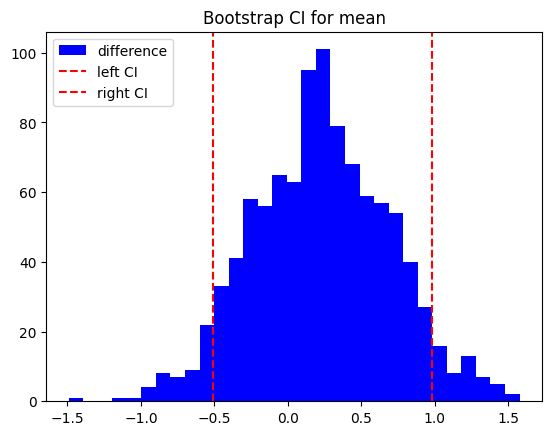

----------------------------------------------------------------------------------------------------
Distributions: norm, norm+uniform
t-test
Принимаем H0: распределения могут быть одинаковыми
mann whitney
Принимаем H0: распределения могут быть одинаковыми
Statistic: median, CI(5.0%): (1.01, -0.51)


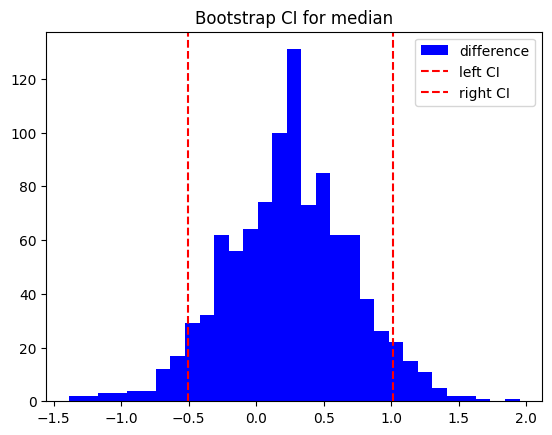

----------------------------------------------------------------------------------------------------
Distributions: norm, norm+uniform
t-test
Принимаем H0: распределения могут быть одинаковыми
mann whitney
Принимаем H0: распределения могут быть одинаковыми
Statistic: q1, CI(5.0%): (0.61, -1.61)


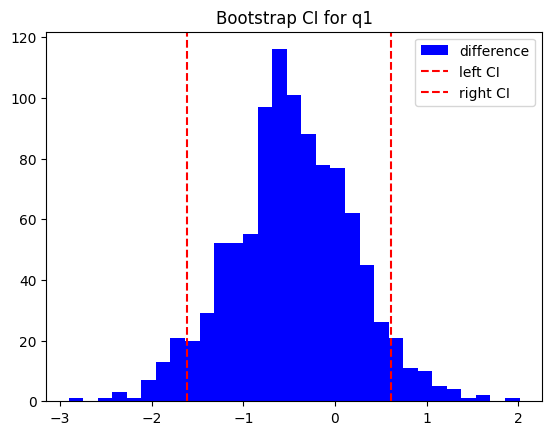

----------------------------------------------------------------------------------------------------
Distributions: norm, norm+norm
t-test
Принимаем H0: распределения могут быть одинаковыми
mann whitney
Принимаем H0: распределения могут быть одинаковыми
Statistic: mean, CI(5.0%): (1.25, -0.23)


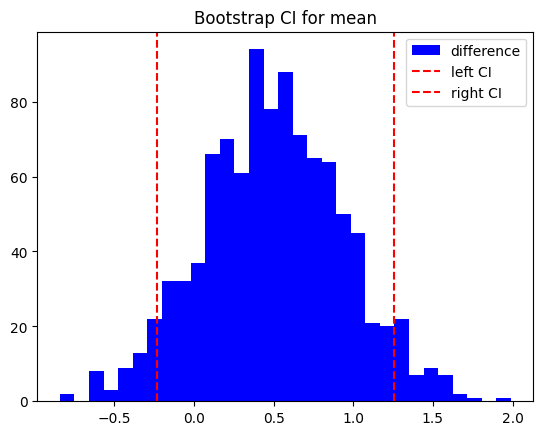

----------------------------------------------------------------------------------------------------
Distributions: norm, norm+norm
t-test
Принимаем H0: распределения могут быть одинаковыми
mann whitney
Принимаем H0: распределения могут быть одинаковыми
Statistic: median, CI(5.0%): (1.27, -0.21)


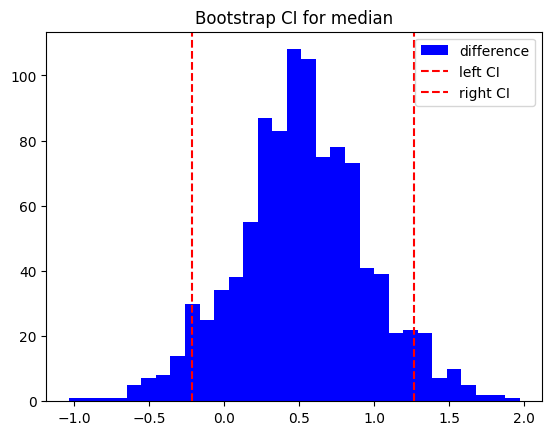

----------------------------------------------------------------------------------------------------
Distributions: norm, norm+norm
t-test
Принимаем H0: распределения могут быть одинаковыми
mann whitney
Принимаем H0: распределения могут быть одинаковыми
Statistic: q1, CI(5.0%): (1.55, -0.64)


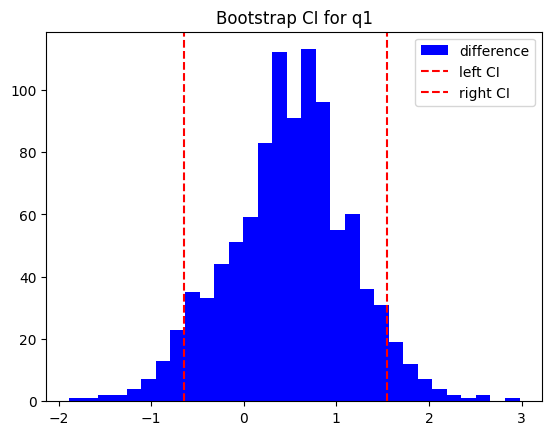

----------------------------------------------------------------------------------------------------
Distributions: norm+outlier, norm+uniform+outlier
t-test
Принимаем H0: распределения могут быть одинаковыми
mann whitney
Принимаем H0: распределения могут быть одинаковыми
Statistic: mean, CI(5.0%): (1.27, -0.47)


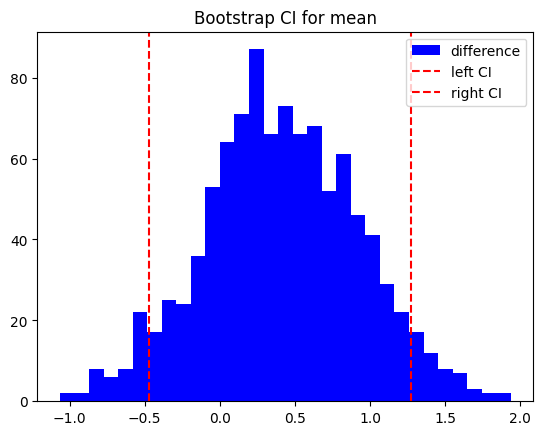

----------------------------------------------------------------------------------------------------
Distributions: norm+outlier, norm+uniform+outlier
t-test
Принимаем H0: распределения могут быть одинаковыми
mann whitney
Принимаем H0: распределения могут быть одинаковыми
Statistic: median, CI(5.0%): (1.16, -0.54)


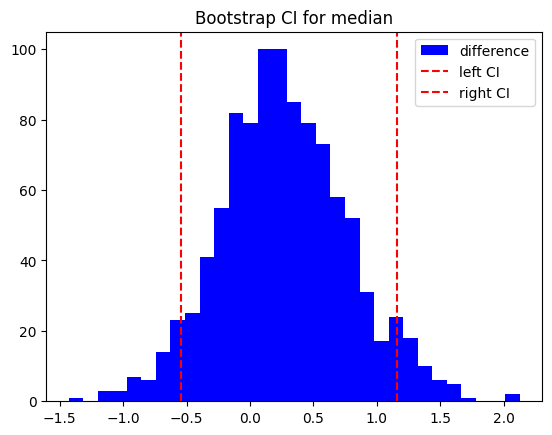

----------------------------------------------------------------------------------------------------
Distributions: norm+outlier, norm+uniform+outlier
t-test
Принимаем H0: распределения могут быть одинаковыми
mann whitney
Принимаем H0: распределения могут быть одинаковыми
Statistic: q1, CI(5.0%): (0.77, -1.58)


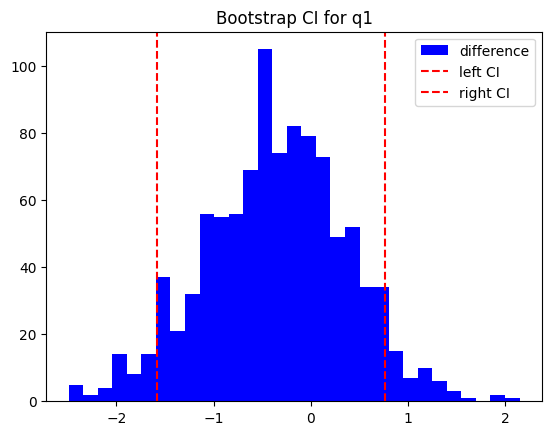

----------------------------------------------------------------------------------------------------
Distributions: norm+outlier, norm+norm+outlier
t-test
Принимаем H0: распределения могут быть одинаковыми
mann whitney
Принимаем H0: распределения могут быть одинаковыми
Statistic: mean, CI(5.0%): (1.07, -0.51)


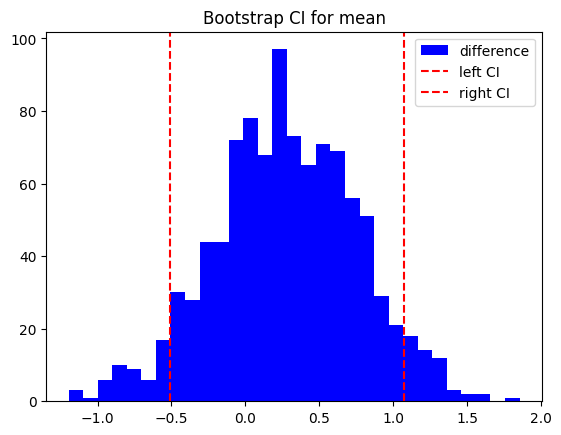

----------------------------------------------------------------------------------------------------
Distributions: norm+outlier, norm+norm+outlier
t-test
Принимаем H0: распределения могут быть одинаковыми
mann whitney
Принимаем H0: распределения могут быть одинаковыми
Statistic: median, CI(5.0%): (1.16, -0.31)


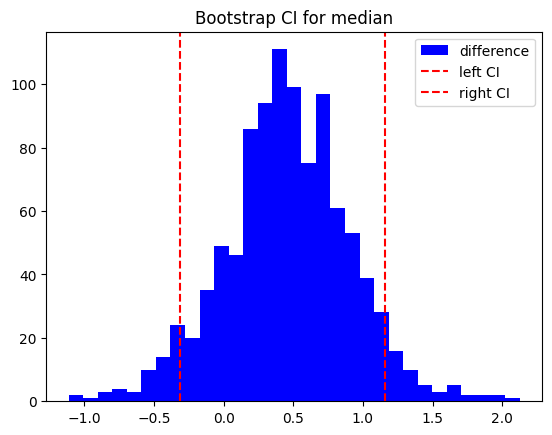

----------------------------------------------------------------------------------------------------
Distributions: norm+outlier, norm+norm+outlier
t-test
Принимаем H0: распределения могут быть одинаковыми
mann whitney
Принимаем H0: распределения могут быть одинаковыми
Statistic: q1, CI(5.0%): (1.43, -0.70)


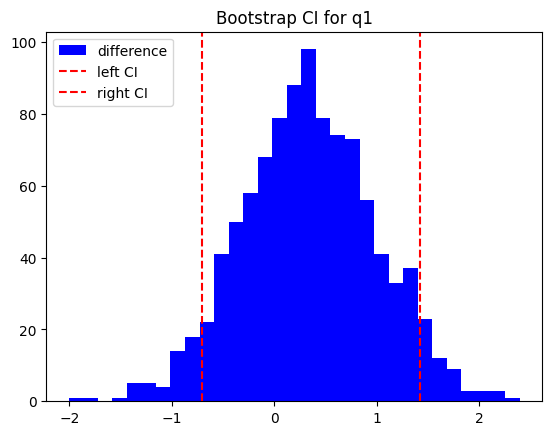

In [68]:
def q1(data: NDArray) -> np.float64:
    return np.percentile(data, 25)

statistics = (
    np.mean,
    np.median,
    q1
)

n_boot = 1000
alpha = .05

dists = (
    (dist, "norm"),
    (dist_uniform, "norm+uniform"),
    (dist_dist, "norm+norm"),
    (dist_outlier, "norm+outlier"),
    (dist_uniform_outlier, "norm+uniform+outlier"),
    (dist_dist_outlier, "norm+norm+outlier"),
)

pairs = (
    (0, 1),
    (0, 2),
    (3, 4),
    (3, 5),
)

for i, j in pairs:
    for stat in statistics:
        d1, nm1 = dists[i]
        d2, nm2 = dists[j]
        print('-'*100)
        print(f"Distributions: {nm1}, {nm2}")
        print(f"t-test")
        do_ttest(d1, d2)
        print(f"mann whitney")
        do_mann_whitney(d1, d2)
        test_with_bootstrap((d1, d2), stat, n_boot, alpha)

## Задача 8 (2 балла)

Сгенерировать 2 выборки из нормального распределения с 1000 элементов каждая.
- Оцените на этих данных мощность и корректность t-test и Манна-Уитни
- Докиньте выбросы в обе группы и проверьте как изменится мощность и корректность

Для оценки использовать минимум 1000 итераций

In [ ]:
import numpy as np
from tqdm import tqdm
from sklearn.utils import resample
from scipy import stats

def bootstrap_mean(data, num_samples=1000):
    means = []
    for _ in range(num_samples):
        sample = resample(data)
        means.append(np.mean(sample))
    return np.array(means)

def assess_power(sample1, sample2, iterations=2000):
    t_test_power = 0
    mw_power = 0
    for _ in tqdm(range(iterations)):
        resampled_sample1 = np.random.choice(sample1, size=len(sample1), replace=True)
        resampled_sample2 = np.random.choice(sample2, size=len(sample2), replace=True)
        
        t_test_result = stats.ttest_ind(resampled_sample1, resampled_sample2)
        if t_test_result.pvalue < 0.05:
            t_test_power += 1
        
        mw_result = stats.mannwhitneyu(resampled_sample1, resampled_sample2)
        if mw_result.pvalue < 0.05:
            mw_power += 1
            
    t_test_power_rate = t_test_power / iterations
    mw_power_rate = mw_power / iterations
    return t_test_power_rate, mw_power_rate

def check_correctness(sample1, sample2, iterations=2000):
    t_test_correctness = []
    mw_correctness = []
    
    for _ in tqdm(range(iterations)):
        resampled_sample1 = np.random.choice(sample1, size=len(sample1), replace=True)
        resampled_sample2 = np.random.choice(sample2, size=len(sample2), replace=True)
        
        mean_a = bootstrap_mean(resampled_sample1)
        mean_b = bootstrap_mean(resampled_sample2)
        
        lower_bound, upper_bound = np.percentile(mean_a - mean_b, [100 * 0.05 / 2., 100 * (1 - 0.05 / 2.)])
        t_test_correctness.append(not lower_bound <= 0 <= upper_bound)
        
        lower_bound_mw, upper_bound_mw = np.percentile(np.median(mean_a) - np.median(mean_b), [100 * 0.05 / 2., 100 * (1 - 0.05 / 2.)])
        mw_correctness.append(not lower_bound_mw <= 0 <= upper_bound_mw)
        
    t_test_correctness_rate = sum(t_test_correctness) / iterations
    mw_correctness_rate = sum(mw_correctness) / iterations
    return t_test_correctness_rate, mw_correctness_rate


In [152]:
sample1 = np.random.normal(loc=0, scale=1, size=1000)
sample2 = np.random.normal(loc=0, scale=1, size=1000)

In [ ]:
power_ttest, power_mw = assess_power(sample1, sample2)
correctness_ttest, correctness_mw = assess_power(sample1, sample2)

100%|██████████| 2000/2000 [14:51<00:00,  2.24it/s]


In [ ]:
print(f"power t-test: {power_ttest:.6f}")
print(f"power mann whitney: {power_mw:.6f}")

print(f"correctness t-test: {correctness_ttest:.6f}")
print(f"correctness mann whitney: {correctness_mw:.6f}")

In [ ]:
sample1_outliers = np.concatenate([sample1, np.random.uniform(low=-10, high=-5, size=10)])
sample2_outliers = np.concatenate([sample2, np.random.uniform(low=5, high=10, size=10)])

In [156]:
power_ttest_o, power_mw_o = assess_power(sample1_outliers, sample2_outliers)
correctness_ttest_o, correctness_mw_o = assess_power(sample1_outliers, sample2_outliers)

NameError: name 'assess_power' is not defined

In [ ]:
print(f"power t-test: {power_ttest_o:.6f}")
print(f"power mann whitney: {power_mw_o:.6f}")

print(f"correctness t-test: {correctness_ttest_o:.6f}")
print(f"correctness mann whitney: {correctness_mw_o:.6f}")